# Step 2 -- Building the Baseline Equation using OLS

### Importing needed modules for this step because the code won't run if we don't. Also getting the raw data we need from our data folder.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

RAW = Path("data/raw")
OUT = Path("data/processed")
OUT.mkdir(parents=True, exist_ok=True)

### Need all of the Fred API columns we are using so that we can run each notebook independently.

In [4]:
SERIES = {
    "INDPRO":   "log_diff", "RSAFS":   "log_diff", "PAYEMS":  "log_diff",
    "UNRATE":   "diff",     "HOUST":   "log_diff", "PCE":     "log_diff",
    "DGORDER":  "log_diff",    "ICSA":    "log_diff",
    "T10Y2Y":   "level",
}
TARGET = "A191RL1Q225SBEA"

### Load the raw series we got in step 1 into pandas so we can use the data properly.  

In [5]:
def load_series(code):
    df = pd.read_csv(RAW / f"{code}.csv", index_col=0, parse_dates=True)
    s = df.iloc[:, 0]
    s.name = code
    return s

def load_all(codes):
    return {c: load_series(c) for c in codes}

raw = load_all(SERIES.keys())
gdp = load_series(TARGET)

### Transforming our data into the logs-differnces (if applicable) as OLS requires stationarity to produce a good output and Log Differences does just that as we learned during the semester. 

In [6]:
def transform(s, rule):
    if rule == "log_diff":
        return np.log(s.replace(0, np.nan)).diff()
    if rule == "diff":
        return s.diff()
    return s

def transform_all(data, rules):
    return {c: transform(s, rules[c]) for c, s in data.items()}

transformed = transform_all(raw, SERIES)

### Most our series columns are monthly signals so we have to make it quarterly to actually make our bridge equation. Quarterly mean is one of the simplest bridge aggregator. 

In [7]:
def to_monthly(s):
    return s.resample("ME").mean()

def to_quarterly(s):
    return to_monthly(s).resample("QE").mean()

def aggregate_panel(data):
    cols = {c: to_quarterly(s) for c, s in data.items()}
    return pd.DataFrame(cols)

X_q = aggregate_panel(transformed)

### Moves GDP growth onto a quarter-end index and inner-joins it with the quarterly regressors. This is needed as bridge equation assumes that each row (at time "X") combines the indicators observed during quarter X with that quarter's GDP outcome.

In [8]:
def align_quarterly(panel, y):
    y_q = y.copy()
    y_q.index = y_q.index.to_period("Q").to_timestamp("Q")
    y_q.name = "gdp_growth"
    return panel.join(y_q, how="inner").dropna()

panel = align_quarterly(X_q, gdp)
panel.tail()

,INDPRO,RSAFS,PAYEMS,UNRATE,HOUST,PCE,DGORDER,ICSA,T10Y2Y,gdp_growth
2024-12-31,0.001728,0.006670,0.000852,0.000000,0.036493,0.006012,-0.002184,-0.005924,0.129106,1.9
2025-03-31,0.002361,0.002457,0.000128,0.033333,-0.036985,0.002730,0.028205,0.004606,0.302891,-0.6
2025-06-30,0.001442,0.000213,0.000213,-0.033333,0.006577,0.002975,-0.004728,0.003721,0.499913,3.8
2025-09-30,0.000622,0.004196,0.000147,0.100000,-0.013286,0.005293,0.002541,-0.003439,0.540801,4.4
2025-12-31,-0.000186,0.001148,-0.000244,-0.100000,0.014490,0.003806,0.007548,-0.008193,0.575539,0.5


### Need our train/test split and since this is time series, need to train with earliest data and evaluate on later data to avoid look ahead bias.  

In [9]:
SPLIT = "2015-01-01"

def split_panel(panel, cutoff):
    train = panel.loc[panel.index < cutoff]
    test = panel.loc[panel.index >= cutoff]
    return train, test

train, test = split_panel(panel, SPLIT)

### Fitting Bridge Equation through OLS because need a way to estimate the coefficients of the Bridge Equation, and OLS is a transparent and straightforward way to give this coeffs. estimates. 

In [10]:
def fit_bridge(train_df):
    X = train_df.drop(columns=["gdp_growth"])
    y = train_df["gdp_growth"]
    model = LinearRegression().fit(X, y)
    return model

bridge = fit_bridge(train)

### Try on new data and returning metrics like RMSE and MAE to see how well it performs. Will allow us to have direct comparisons when comparing it to our future models -- good for our results/discussion section. 

In [11]:
def score(model, df):
    X = df.drop(columns=["gdp_growth"])
    y = df["gdp_growth"]
    pred = model.predict(X)
    rmse = float(np.sqrt(mean_squared_error(y, pred)))
    mae = float(mean_absolute_error(y, pred))
    return {"rmse": rmse, "mae": mae, "pred": pred, "actual": y.values, "idx": y.index}

res = score(bridge, test)
{"rmse": res["rmse"], "mae": res["mae"]}

{'rmse': 3.833872700934932, 'mae': 1.9469401169296148}

### Saving these predictions into .csv file so later notebooks (which will need to use them) do not need to depend on this notebook and can call the data right away. 

In [12]:
def save_predictions(res, path):
    out = pd.DataFrame({"actual": res["actual"], "bridge_pred": res["pred"]},
                       index=res["idx"])
    out.to_csv(path)

save_predictions(res, OUT / "bridge_predictions.csv")

### Just a sanity check to ensure I am actualy doing this right, doesn't affect anything downstream. 

In [13]:
def coef_table(model, feature_names):
    return pd.DataFrame({"feature": feature_names,
                         "coef": model.coef_}).sort_values("coef", key=abs,
                                                          ascending=False)

coef_table(bridge, train.drop(columns=["gdp_growth"]).columns)

,feature,coef
5,PCE,360.599021
2,PAYEMS,126.219391
0,INDPRO,105.199095
1,RSAFS,-58.881234
6,DGORDER,16.867928
4,HOUST,6.960801
3,UNRATE,-5.424040
7,ICSA,-3.655171
8,T10Y2Y,-0.209353


### Another sanity check, but visual this time 

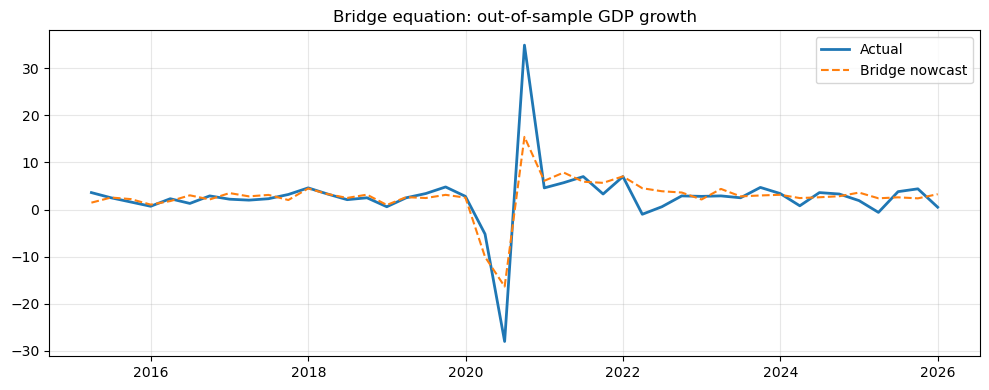

In [14]:
def plot_fit(res):
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(res["idx"], res["actual"], label="Actual", linewidth=2)
    ax.plot(res["idx"], res["pred"], label="Bridge nowcast", linestyle="--")
    ax.set_title("Bridge equation: out-of-sample GDP growth")
    ax.legend(); ax.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

plot_fit(res)

Not bad :) 